# 01 · PCA for compression

**Question:** how many principal components keep 95% of MNIST's variance, how much smaller does the data get, and how close are the decompressed images to the originals?

Method: Géron, *Hands-On Machine Learning* (2nd ed.), Chapter 8, sections *PCA*, *Choosing the Right Number of Dimensions* and *PCA for Compression* (pp. 222-227). The pipeline runs the same code (`dimred_mlops.compression`); this notebook walks through it step by step.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dimred_mlops.config import load_config
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
CFG = load_config(ROOT / "configs/full_flow_config.yaml")
SEED = CFG["seed"]
# figures are drawn into a temporary folder: reports/figures belongs to the pipeline run
import tempfile
FIG = Path(tempfile.mkdtemp(prefix="nb-figures-"))

In [2]:
from dimred_mlops.data import load_mnist_split
split = load_mnist_split(ROOT / "data")     # first 60,000 = train, last 10,000 = test
X_train, y_train, X_test, y_test = split.X_train, split.y_train, split.X_test, split.y_test
split.sizes

{'n_train': 60000, 'n_test': 10000, 'n_features': 784}

## 1. Principal components with NumPy's SVD (the book's code, p. 223)

PCA needs centred data. The rows of `Vt` are the principal components. scikit-learn's `PCA` must find the same axes, up to sign (p. 223 warns that their direction is not stable).

In [3]:
from sklearn.decomposition import PCA
X_centered = X_train - X_train.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered.astype(np.float64), full_matrices=False)
c1, c2 = Vt[0], Vt[1]
pca2 = PCA(n_components=2, svd_solver="full").fit(X_train)
print("|cos(c1, sklearn PC1)| =", abs(c1 @ pca2.components_[0]).round(6))
print("|cos(c2, sklearn PC2)| =", abs(c2 @ pca2.components_[1]).round(6))
print("explained variance ratio of PC1, PC2:", pca2.explained_variance_ratio_.round(4))

|cos(c1, sklearn PC1)| = 1.0
|cos(c2, sklearn PC2)| = 1.0
explained variance ratio of PC1, PC2: [0.097 0.071]


## 2. Choosing the number of dimensions (p. 225)

Two equivalent recipes: the smallest `d` with cumulative explained variance ≥ 95%, or `PCA(n_components=0.95)`.

In [4]:
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
pca95 = PCA(n_components=0.95).fit(X_train)
print("d =", d, "| PCA(0.95) keeps", pca95.n_components_, "components |", f"{d / 784:.1%} of the 784 features")
pd.DataFrame({"variance": [0.5, 0.8, 0.9, 0.95, 0.99],
              "d": [int(np.argmax(cumsum >= v) + 1) for v in [0.5, 0.8, 0.9, 0.95, 0.99]]})

d = 154 | PCA(0.95) keeps 154 components | 19.6% of the 784 features


,variance,d
0,0.50,11
1,0.80,44
2,0.90,87
3,0.95,154
4,0.99,331


## 3. The full experiment (Part A of the pipeline)

`run_part_a` fits one PCA with all 784 components. Each compression level keeps its first `d` components (Equations 8-2 and 8-3), and the test set measures how much variance survives compression followed by decompression.

In [5]:
from dimred_mlops.compression import run_part_a
a = run_part_a(split, CFG["part_a"], SEED)
a.variance_table.round(4)

,variance_target,n_components,pct_of_features,train_explained_variance,test_explained_variance,train_mse,test_mse,test_rmse_pixels
0,0.50,11,1.4031,0.5092,0.5155,2146.0945,2123.8883,46.0857
1,0.80,44,5.6122,0.8033,0.8087,860.2129,838.3521,28.9543
2,0.90,87,11.0969,0.9001,0.9027,436.8372,426.5669,20.6535
3,0.95,154,19.6429,0.9502,0.9510,217.7937,214.7184,14.6533
4,0.99,331,42.2194,0.9900,0.9902,43.6736,42.9824,6.5561


In [6]:
pd.Series(a.metrics).round(4)

n_components_95                  154.0000
pct_of_features_95                19.6429
train_explained_variance_95        0.9502
test_explained_variance_95         0.9510
train_mse_95                     217.7937
test_mse_95                      214.7184
test_rmse_pixels_95               14.6533
dropped_variance_per_pixel_95    217.7936
n_components_99                  331.0000
n_components_50                   11.0000
explained_variance_pc1             0.0970
explained_variance_pc2             0.0710
dtype: float64

**A check from the mathematics** (derived in the technical report): the mean squared reconstruction error on the training set equals the variance of the dropped components divided by the number of pixels.

In [7]:
print("training reconstruction MSE (95%):", round(a.metrics["train_mse_95"], 3))
print("dropped variance per pixel       :", round(a.metrics["dropped_variance_per_pixel_95"], 3))

training reconstruction MSE (95%): 217.794
dropped variance per pixel       : 217.794


## 4. "Less than 20% of its original size": in features or in bytes?

The book compares numbers of features (p. 226). MNIST is stored as one byte per pixel, while PCA codes are floating-point numbers. The saving in bytes therefore depends on the dtype of the codes.

In [8]:
a.storage.round(1)

,representation,values_per_image,bytes_per_value,bytes_per_image,dataset_MB,pct_of_float32_pixels,pct_of_uint8_pixels
0,"raw pixels, uint8 (how MNIST is shipped)",784,1,784,47.0,25.0,100.0
1,"raw pixels, float32",784,4,3136,188.2,100.0,400.0
2,"PCA codes, float32 (154 values)",154,4,616,37.0,19.6,78.6
3,"PCA codes, float16 (154 values)",154,2,308,18.5,9.8,39.3


## 5. Figures

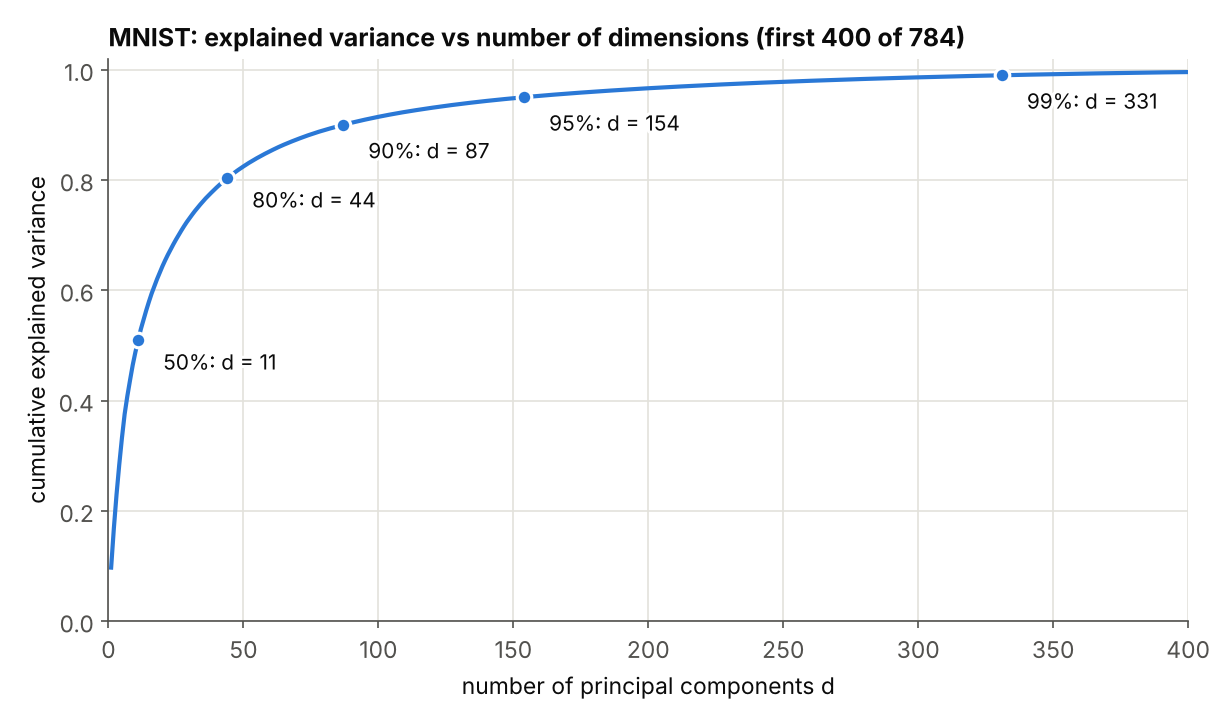

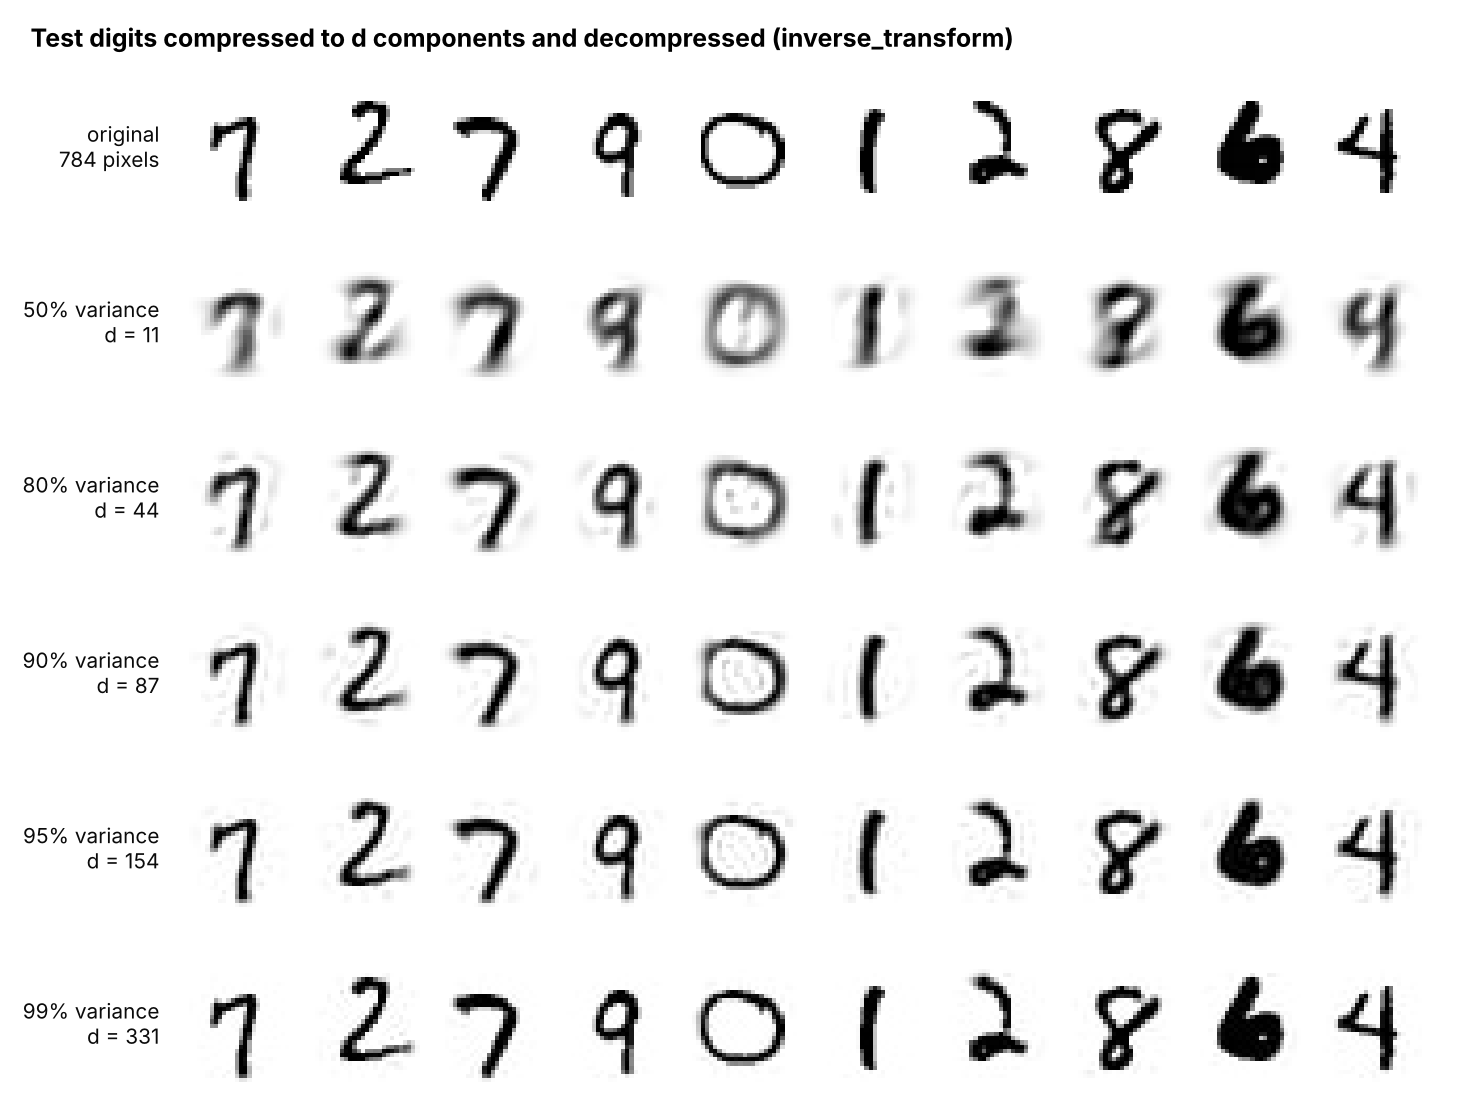

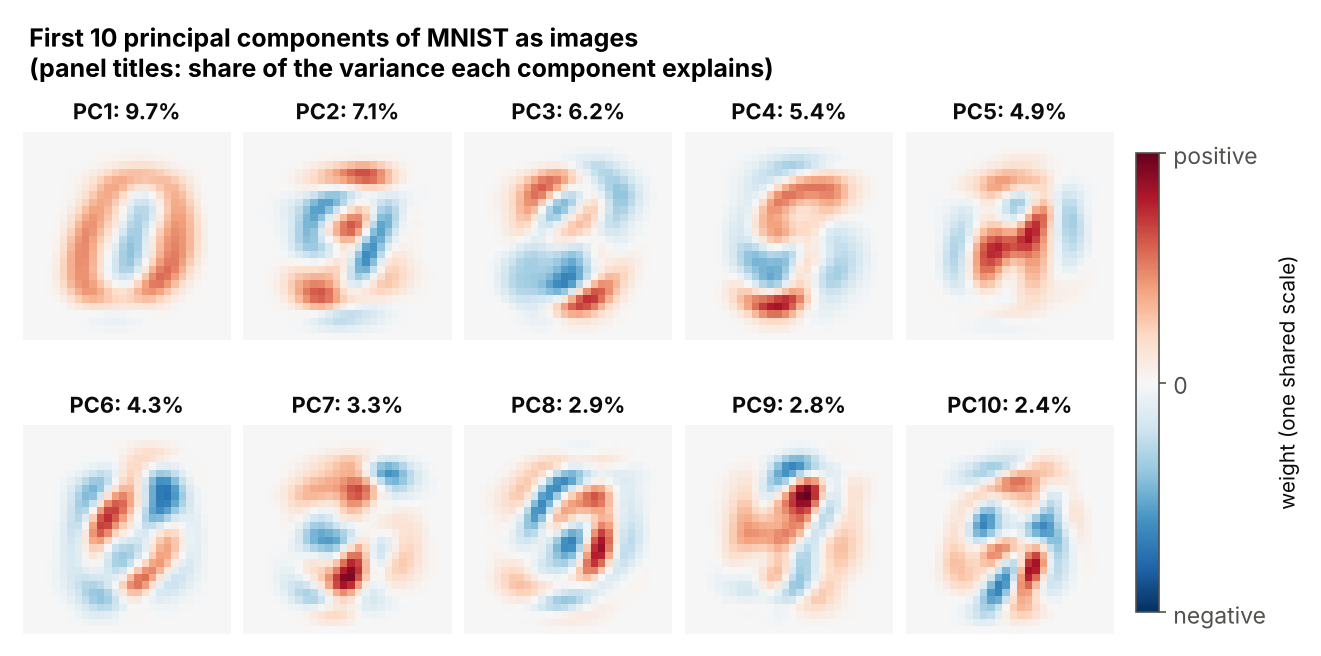

In [9]:
from dimred_mlops import plots
plots.explained_variance(a.cumulative, a.variance_table, FIG / "a_explained_variance.png")
plots.reconstructions(X_test, a.pca_full, a.variance_table, a.example_index, FIG / "a_reconstructions.png")
plots.principal_components(a.pca_full, FIG / "a_principal_components.png")
for f in ["a_explained_variance", "a_reconstructions", "a_principal_components"]:
    display(Image(str(FIG / f"{f}.png"), width=850))

## Takeaways
* 154 of 784 components (19.6% of the features) keep 95.0% of the training variance. This matches the book's "just over 150 features".
* The decompressed test digits keep about 95% of the test-set variance too, so the compression generalises.
* In bytes, float32 codes are 79% of the uint8 MNIST file, not under 20%. float16 codes would be 39%.